# Radio Image Reconstruction

This exploratory notebook runs the project workflow end to end: generate synthetic radio images, train a small CNN or U-Net architecture, and visualize a reconstruction.

Mathematically, the goal is to learn a mapping from a partially sampled radio-interferometric image to the original sky brightness image.

Readable equation:

```text
CNN(dirty image) ~= clean image

or

f_theta(I_dirty) ~= I_clean
```

Here `I_clean` is the simulated true sky, `I_dirty` is the image after Fourier-domain undersampling, and `theta` means the trainable CNN weights.

## 1. Imports and Settings

The images are square arrays with shape `N x N`. In this notebook, `N = 128`, so each image is a grid of real pixel values.

Readable notation:

```text
I[x, y] = brightness value at pixel position (x, y)

x ranges from 0 to N - 1
y ranges from 0 to N - 1
N = 128
```

`n_samples` controls how many paired examples `(I_dirty, I_clean)` are generated. The dataset is split into training, validation, and test parts.

Readable split:

```text
training set   = examples used to update the CNN weights
validation set = examples used to check overfitting during training
test set       = examples used for final measurement only
```

For fair hyperparameter comparison, the synthetic dataset should stay fixed across runs. This notebook uses `random_seed` for reproducibility and `regenerate_dataset = False` to reuse existing generated files.

Readable reproducibility rule:

```text
same dataset + same split + same seed = much fairer comparison
different random dataset              = metrics are not directly comparable
```

`batch_size`, `epochs`, `learning_rate`, `weight_decay`, and `weighted_mse_alpha` are hyperparameters. The device is `cuda` when a GPU is available, otherwise `cpu`.

In [38]:
import os
import glob
import random

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

%matplotlib inline

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

N = 128
n_samples = 1000
batch_size = 8
epochs = 50
learning_rate = 1e-3
weight_decay = 5e-20
weighted_mse_alpha = 1.0
flux_loss_weight = 1e-9
model_path = "radio_cnn_dirty_beam.pth"
model_architecture = "unet"  # Choose "simple_cnn" or "unet"

train_fraction = 0.70
val_fraction = 0.15
test_fraction = 0.15
random_seed = 42
regenerate_dataset = False
recompute_dirty_beams = False

patience = 5
min_delta = 0.0

random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

# These make CUDA runs more repeatable, at a possible speed cost.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Using device: cpu


## 2. Generate or Reuse Fixed Dataset

### Clean sky model

Each clean sky starts as an empty image. A random number of point sources are added.

Readable equation:

```text
initial_sky[x, y] = sum of all point sources at pixel (x, y)

For each source k:
  location  = (x_k, y_k)
  amplitude = a_k

If pixel (x, y) is the source location:
  add a_k to that pixel
```

`K` is randomly chosen between 3 and 9, `(x_k, y_k)` is the source location, and `a_k` is the source amplitude.

The code then applies a Gaussian blur. This spreads each point source into a smooth blob.

Readable equation:

```text
clean_sky = initial_sky convolved with Gaussian(sigma)
```

### Fourier mask and dirty beam

Radio interferometers sample the Fourier domain, often called the `uv` plane. The notebook computes the 2D discrete Fourier transform.

Readable equation:

```text
F = FFT2(clean_sky)

F[u, v] stores how much of a certain spatial frequency
is present in the clean sky image.
```

A random binary mask `M[u, v]` keeps only some Fourier coefficients.

Readable equation:

```text
sampled_F[u, v] = mask[u, v] * F[u, v]

mask[u, v] = 1 means keep this Fourier value
mask[u, v] = 0 means remove this Fourier value
```

The dirty image is made by transforming the sampled Fourier data back into image space.

Readable equation:

```text
dirty_image = absolute_value(IFFT2(sampled_F))
```

The dirty beam is the image-space response caused by the sampling mask.

Readable equation:

```text
dirty_beam = centered_real_part(IFFT2(mask))
dirty_beam = dirty_beam / peak_absolute_value
```

This notebook now saves all four arrays for each sample:

```text
data/clean/i.npy  -> true sky
data/dirty/i.npy  -> dirty image
data/mask/i.npy   -> Fourier sampling mask
data/beam/i.npy   -> centered, signed, peak-normalized dirty beam
```

For reproducibility, the dataset is generated only when needed. If all expected `.npy` files already exist and `regenerate_dataset = False`, the notebook reuses them.

In [39]:
os.makedirs("data/dirty", exist_ok=True)
os.makedirs("data/clean", exist_ok=True)
os.makedirs("data/mask", exist_ok=True)
os.makedirs("data/beam", exist_ok=True)

def create_sky():
    img = np.zeros((N, N))
    n_sources = np.random.randint(3, 10)

    for _ in range(n_sources):
        x = np.random.randint(10, N - 10)
        y = np.random.randint(10, N - 10)
        amp = np.random.uniform(0.5, 1.0)
        img[x, y] += amp

    return gaussian_filter(img, sigma=np.random.uniform(1, 3))

def make_dirty_image(clean_img):
    ft = np.fft.fftshift(np.fft.fft2(clean_img))
    mask = (np.random.rand(N, N) > 0.7).astype(float)
    sampled = ft * mask
    dirty = np.abs(np.fft.ifft2(np.fft.ifftshift(sampled)))
    dirty_beam = compute_dirty_beam(mask)
    return dirty, mask, dirty_beam

def compute_dirty_beam(mask):
    dirty_beam = np.fft.fftshift(np.real(np.fft.ifft2(np.fft.ifftshift(mask))))
    dirty_beam = dirty_beam / (np.max(np.abs(dirty_beam)) + 1e-12)
    return dirty_beam

clean_files = sorted(glob.glob("data/clean/*.npy"))
dirty_files = sorted(glob.glob("data/dirty/*.npy"))
mask_files = sorted(glob.glob("data/mask/*.npy"))
beam_files = sorted(glob.glob("data/beam/*.npy"))
dataset_is_complete = (
    len(clean_files) == n_samples
    and len(dirty_files) == n_samples
    and len(mask_files) == n_samples
    and len(beam_files) == n_samples
)

if dataset_is_complete and not regenerate_dataset:
    print(f"Reusing fixed dataset with {n_samples} samples, masks, and dirty beams.")
    print("Set regenerate_dataset = True in the settings cell to create a new seeded dataset.")

    if recompute_dirty_beams:
        for i in range(n_samples):
            mask = np.load(f"data/mask/{i}.npy")
            dirty_beam = compute_dirty_beam(mask)
            np.save(f"data/beam/{i}.npy", dirty_beam)
        print("Recomputed centered, signed, peak-normalized dirty beams from saved masks.")
else:
    np.random.seed(random_seed)

    for i in range(n_samples):
        clean = create_sky()
        dirty, mask, dirty_beam = make_dirty_image(clean)
        np.save(f"data/clean/{i}.npy", clean)
        np.save(f"data/dirty/{i}.npy", dirty)
        np.save(f"data/mask/{i}.npy", mask)
        np.save(f"data/beam/{i}.npy", dirty_beam)

    print(f"Generated fixed dataset with {n_samples} samples using random_seed = {random_seed}.")
    print("Saved clean images, dirty images, masks, and dirty beams.")

Reusing fixed dataset with 1000 samples, masks, and dirty beams.
Set regenerate_dataset = True in the settings cell to create a new seeded dataset.


## 3. Preview One Sample

This cell visualizes one training pair plus the Fourier sampling mask and dirty beam.

Readable interpretation:

```text
clean image = target sky brightness
dirty image = incomplete Fourier observation transformed back to image space
mask        = sampled Fourier locations
dirty beam  = image-space imprint of the sampling mask
```

The dirty image can also be viewed as a convolution effect.

Readable equation:

```text
dirty_image ~= clean_image convolved with dirty_beam

dirty_beam = IFFT2(mask)
```

Because the mask removes Fourier information, the inverse problem is not perfectly determined. The CNN learns a statistical reconstruction from many examples.

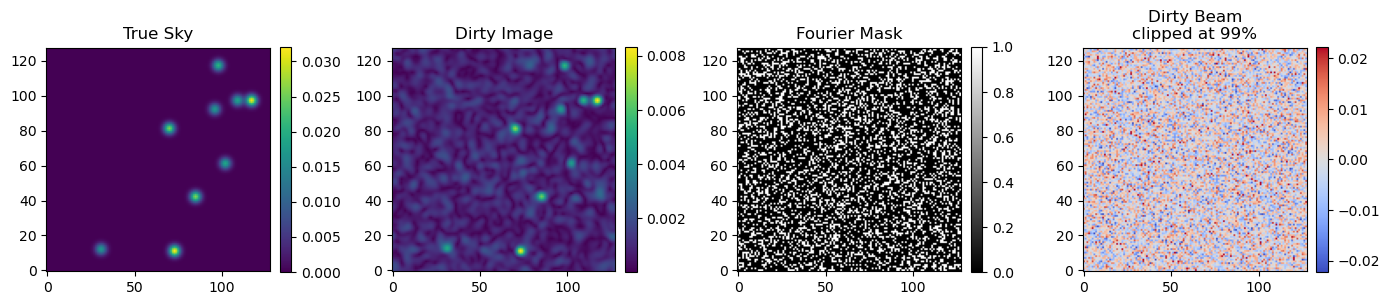

In [40]:
sample_id = 0
clean = np.load(f"data/clean/{sample_id}.npy")
dirty = np.load(f"data/dirty/{sample_id}.npy")
mask = np.load(f"data/mask/{sample_id}.npy")
dirty_beam = np.load(f"data/beam/{sample_id}.npy")

plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(clean, origin="lower")
plt.title("True Sky")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 4, 2)
plt.imshow(dirty, origin="lower")
plt.title("Dirty Image")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 4, 3)
plt.imshow(mask, origin="lower", cmap="gray")
plt.title("Fourier Mask")
plt.colorbar(fraction=0.046, pad=0.04)

beam_display_limit = np.percentile(np.abs(dirty_beam), 99)

plt.subplot(1, 4, 4)
plt.imshow(
    dirty_beam,
    origin="lower",
    cmap="coolwarm",
    vmin=-beam_display_limit,
    vmax=beam_display_limit,
)
plt.title("Dirty Beam\nclipped at 99%")
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("data_example.png", dpi=150)
plt.show()

## 4. Dataset and Model

### Dataset tensors

Each saved NumPy image has shape `(N, N)`. PyTorch convolution layers expect tensors with four dimensions.

Readable shape notation:

```text
(batch, channels, height, width)
```

The model now uses two input channels:

```text
channel 0 = dirty image
channel 1 = dirty beam
target    = clean image
```

So each input sample has shape `(2, N, N)`. A batch of 8 images becomes `(8, 2, N, N)`.

### Train/validation/test split

The dirty beam tells the model what image-space artifact pattern was produced by the Fourier mask. That gives the CNN more physical context than the dirty image alone. The model should not be judged only on the same images it trains on, so we split the dataset:

```text
training examples   -> used by optimizer.step()
validation examples -> used to monitor generalization while training
test examples       -> used at the end for final metrics
```

If training loss is low but validation loss is high, that is an overfitting signal. If both are high, that is an underfitting signal.

### SimpleCNN layers

A 2D convolution computes local weighted sums. Each output pixel is built from a small neighborhood of input pixels.

Readable equation:

```text
output pixel = bias + weighted sum of nearby input pixels
```

Here, the model applies six convolutional layers:

```text
2 channels -> 16 channels -> 32 channels -> 64 channels -> 32 channels -> 16 channels -> 1 channel
```

The first `2` means dirty image plus dirty beam. The final `1` is the reconstructed clean-image channel. `padding=1` with a `3 x 3` kernel keeps the spatial size fixed at `128 x 128`.

Between convolution layers, ReLU applies a simple nonlinearity.

Readable equation:

```text
ReLU(z) = z if z > 0
ReLU(z) = 0 if z <= 0
```

The full model is therefore a learned nonlinear function from `(dirty image, dirty beam)` to clean image.

### UNet architecture

U-Net is an encoder-decoder architecture with skip connections, designed to preserve spatial detail while learning hierarchical features. It works in three stages:

**Encoder (downsampling path):**

The encoder progressively reduces spatial dimensions while increasing channel depth:

```text
input (2, 128, 128) -> conv_block -> 16 channels (128 x 128)
                       MaxPool2d   -> downsample by 2x
                       conv_block -> 32 channels (64 x 64)
                       MaxPool2d   -> downsample by 2x
                       conv_block -> 64 channels (32 x 32)
                       MaxPool2d   -> downsample by 2x
```

At each level, `conv_block` performs two sequential convolutions with ReLU activations. MaxPool2d reduces the spatial size but keeps the most important features.

**Bottleneck:**

At the deepest level, the bottleneck processes the most abstract features:

```text
bottleneck conv_block -> 128 channels (16 x 16)
```

This tiny 16x16 representation captures global context.

**Decoder (upsampling path):**

The decoder mirrors the encoder, expanding spatial dimensions back to 128x128. Crucially, it uses **skip connections** to concatenate encoder features at matching resolution levels:

```text
ConvTranspose2d -> upsample to (32 x 32)
concat encoder   -> join with 64-channel encoder output
conv_block       -> 64 channels
ConvTranspose2d -> upsample to (64 x 64)
concat encoder   -> join with 32-channel encoder output
conv_block       -> 32 channels
ConvTranspose2d -> upsample to (128 x 128)
concat encoder   -> join with 16-channel encoder output
conv_block       -> 16 channels
final_conv       -> 1 channel (output)
```

**Skip connections benefit:**

When decoder upsamples, it combines both the upsampled deep features (which have global context) with the high-resolution encoder features (which have fine spatial detail). This fusion helps preserve sharp boundaries and fine structures that would otherwise be lost during downsampling.

Readable equation:

```text
decoder_input_after_upsample = upsampled_features  (e.g., 32 channels)
encoder_skip_connection       = encoder_output     (e.g., 64 channels)
concatenated                  = [decoder, encoder] (96 channels total)
refined_output                = conv_block(concatenated)
```

**Overall U-Net advantage:**

Compared to SimpleCNN, U-Net can learn multi-scale representations more effectively. The encoder learns what to compress; the decoder learns to reconstruct; and skip connections prevent information loss. This often produces cleaner reconstructions with fewer artifacts, especially for complex deconvolution tasks like radio imaging.

In [41]:
class RadioDataset(Dataset):
    def __init__(self):
        self.clean_files = sorted(glob.glob("data/clean/*.npy"))
        self.dirty_files = sorted(glob.glob("data/dirty/*.npy"))
        self.beam_files = sorted(glob.glob("data/beam/*.npy"))

        file_counts = {
            "clean": len(self.clean_files),
            "dirty": len(self.dirty_files),
            "beam": len(self.beam_files),
        }
        if len(set(file_counts.values())) != 1:
            raise ValueError(f"The clean, dirty, and beam folders have different file counts: {file_counts}")
        if not self.clean_files:
            raise ValueError("No dataset files found. Run the dataset generation cell first.")

    def __len__(self):
        return len(self.clean_files)

    def __getitem__(self, idx):
        clean = np.load(self.clean_files[idx])
        dirty = np.load(self.dirty_files[idx])
        dirty_beam = np.load(self.beam_files[idx])

        input_image = np.stack([dirty, dirty_beam], axis=0)

        input_tensor = torch.tensor(input_image, dtype=torch.float32)
        clean_tensor = torch.tensor(clean, dtype=torch.float32).unsqueeze(0)

        return input_tensor, clean_tensor

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, 3, padding=1),
        )

    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=1):
        super().__init__()
        
        # Encoder
        self.enc1 = self.conv_block(in_channels, 16)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.enc2 = self.conv_block(16, 32)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.enc3 = self.conv_block(32, 64)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Bottleneck
        self.bottleneck = self.conv_block(64, 128)
        
        # Decoder
        self.upconv3 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec3 = self.conv_block(128, 64)
        
        self.upconv2 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec2 = self.conv_block(64, 32)
        
        self.upconv1 = nn.ConvTranspose2d(32, 16, 2, 2)
        self.dec1 = self.conv_block(32, 16)
        
        # Output
        self.final_conv = nn.Conv2d(16, out_channels, 1)
    
    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        # Encoder with skip connections
        enc1 = self.enc1(x)
        x = self.pool1(enc1)
        
        enc2 = self.enc2(x)
        x = self.pool2(enc2)
        
        enc3 = self.enc3(x)
        x = self.pool3(enc3)
        
        # Bottleneck
        x = self.bottleneck(x)
        
        # Decoder with skip connections
        x = self.upconv3(x)
        x = torch.cat([x, enc3], dim=1)
        x = self.dec3(x)
        
        x = self.upconv2(x)
        x = torch.cat([x, enc2], dim=1)
        x = self.dec2(x)
        
        x = self.upconv1(x)
        x = torch.cat([x, enc1], dim=1)
        x = self.dec1(x)
        
        x = self.final_conv(x)
        return x

dataset = RadioDataset()
n_total = len(dataset)
n_train = int(train_fraction * n_total)
n_val = int(val_fraction * n_total)
n_test = n_total - n_train - n_val

generator = torch.Generator().manual_seed(random_seed)
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [n_train, n_val, n_test], generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Instantiate model based on architecture selection
if model_architecture.lower() == "simple_cnn":
    model = SimpleCNN().to(device)
    print(f"Using SimpleCNN architecture")
elif model_architecture.lower() == "unet":
    model = UNet(in_channels=2, out_channels=1).to(device)
    print(f"Using UNet architecture")
else:
    raise ValueError(f"Unknown architecture: {model_architecture}. Choose 'simple_cnn' or 'unet'.")

example_input, example_target = dataset[0]
print(f"Total samples: {n_total}")
print(f"Train: {len(train_dataset)}, Validation: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Example input shape: {tuple(example_input.shape)}")
print(f"Example target shape: {tuple(example_target.shape)}")

Using UNet architecture
Total samples: 1000
Train: 700, Validation: 150, Test: 150
Example input shape: (2, 128, 128)
Example target shape: (1, 128, 128)


## 5. Train With Validation Diagnostics

For each dirty image `X = I_dirty` and dirty beam `B`, the network predicts a reconstructed image.

Readable equation:

```text
prediction = CNN(dirty_image, dirty_beam)
```

The target is the clean image `Y = I_clean`. This notebook uses simple weighted MSE plus an optional small flux-conservation term.

Readable weighted MSE:

```text
weight = 1 + weighted_mse_alpha * clean_pixel
error = prediction_pixel - clean_pixel
weighted_squared_error = weight * error * error

weighted MSE = average weighted_squared_error over all pixels in the batch
```

Readable flux loss:

```text
predicted_flux = sum of all reconstructed pixels
clean_flux     = sum of all clean-image pixels
flux_error     = (predicted_flux - clean_flux) / clean_flux
flux_loss      = flux_error * flux_error

total_loss = weighted_MSE + flux_loss_weight * flux_loss
```

Use `flux_loss_weight = 0.0` to disable flux loss. Good small values to try are `1e-4` and `3e-4`. Avoid large values at first because they can destabilize the image.

During each epoch, we track two validation numbers:

```text
validation total loss = same loss used for model selection
validation MSE        = ordinary MSE for easy comparison
```

In [42]:
mse_criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

def weighted_mse_loss(pred, target, alpha=10.0):
    weight = 1.0 + alpha * target
    return (weight * (pred - target) ** 2).mean()

def relative_flux_loss(pred, target):
    pred_flux = pred.sum(dim=(1, 2, 3))
    target_flux = target.sum(dim=(1, 2, 3)).clamp_min(1e-12)
    flux_error = (pred_flux - target_flux) / target_flux
    return (flux_error ** 2).mean()

def reconstruction_loss(pred, target):
    mse_loss = weighted_mse_loss(pred, target, alpha=weighted_mse_alpha)
    flux_loss = relative_flux_loss(pred, target)
    return mse_loss + flux_loss_weight * flux_loss

history = {"train_loss": [], "val_loss": [], "val_mse": []}
best_val_loss = float("inf")
best_epoch = 0
best_state = None
epochs_without_improvement = 0

for epoch in range(epochs):
    model.train()
    train_loss_sum = 0.0
    train_count = 0

    for input_batch, clean_batch in train_loader:
        input_batch = input_batch.to(device)
        clean_batch = clean_batch.to(device)

        pred = model(input_batch)
        loss = reconstruction_loss(pred, clean_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_count = input_batch.size(0)
        train_loss_sum += loss.item() * batch_count
        train_count += batch_count

    train_loss = train_loss_sum / train_count

    model.eval()
    val_loss_sum = 0.0
    val_mse_sum = 0.0
    val_count = 0

    with torch.no_grad():
        for input_batch, clean_batch in val_loader:
            input_batch = input_batch.to(device)
            clean_batch = clean_batch.to(device)

            pred = model(input_batch)
            loss = reconstruction_loss(pred, clean_batch)
            mse = mse_criterion(pred, clean_batch)

            batch_count = input_batch.size(0)
            val_loss_sum += loss.item() * batch_count
            val_mse_sum += mse.item() * batch_count
            val_count += batch_count

    val_loss = val_loss_sum / val_count
    val_mse = val_mse_sum / val_count
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_mse"].append(val_mse)

    improved = val_loss < best_val_loss - min_delta
    if improved:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
        marker = "best"
    else:
        epochs_without_improvement += 1
        marker = f"no improvement {epochs_without_improvement}/{patience}"

    print(
        f"Epoch {epoch + 1:02d}/{epochs}, "
        f"Train Loss = {train_loss:.6f}, "
        f"Val Loss = {val_loss:.6f}, "
        f"Val MSE = {val_mse:.6f} ({marker})"
    )

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch + 1}.")
        break

if best_state is not None:
    model.load_state_dict(best_state)

torch.save(model.state_dict(), model_path)
print(f"Saved best validation model from epoch {best_epoch} to {model_path}. Best Val Loss = {best_val_loss:.6f}")

Epoch 01/50, Train Loss = 0.000088, Val Loss = 0.000007, Val MSE = 0.000006 (best)
Epoch 02/50, Train Loss = 0.000007, Val Loss = 0.000006, Val MSE = 0.000006 (best)
Epoch 03/50, Train Loss = 0.000006, Val Loss = 0.000006, Val MSE = 0.000005 (best)
Epoch 04/50, Train Loss = 0.000006, Val Loss = 0.000006, Val MSE = 0.000005 (best)
Epoch 05/50, Train Loss = 0.000006, Val Loss = 0.000006, Val MSE = 0.000005 (best)
Epoch 06/50, Train Loss = 0.000006, Val Loss = 0.000006, Val MSE = 0.000005 (best)
Epoch 07/50, Train Loss = 0.000006, Val Loss = 0.000006, Val MSE = 0.000005 (best)
Epoch 08/50, Train Loss = 0.000006, Val Loss = 0.000006, Val MSE = 0.000005 (best)
Epoch 09/50, Train Loss = 0.000006, Val Loss = 0.000006, Val MSE = 0.000005 (best)
Epoch 10/50, Train Loss = 0.000006, Val Loss = 0.000006, Val MSE = 0.000005 (best)
Epoch 11/50, Train Loss = 0.000006, Val Loss = 0.000006, Val MSE = 0.000005 (best)
Epoch 12/50, Train Loss = 0.000006, Val Loss = 0.000005, Val MSE = 0.000005 (best)
Epoc

## 6. Diagnose Bias and Variance

This section plots training weighted loss and validation weighted loss together. The shape of this curve is the main diagnostic tool. It also plots ordinary validation MSE so you can compare runs even when `weighted_mse_alpha` changes.

Readable rules:

```text
underfitting / high bias:
  train loss is high
  validation loss is also high

overfitting / high variance:
  train loss keeps going down
  validation loss stops improving or starts going up

good fit:
  train loss goes down
  validation loss goes down
  the gap between them stays small
```

With weighted MSE, inspect the residual image too. The goal is not only lower MSE, but less structured positive residual near bright sources.

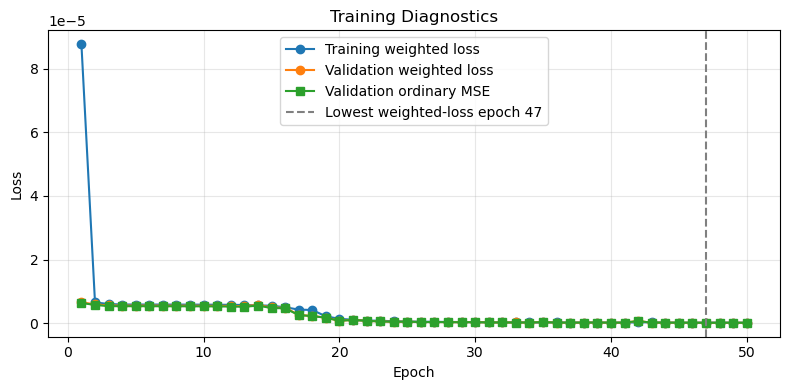

Final training weighted loss:   0.000000
Final validation weighted loss: 0.000000
Final validation ordinary MSE:  0.000000
Lowest plotted weighted loss:   0.000000 at epoch 47
Saved model epoch:              47
Validation/train ratio:         0.85
Diagnostic hint: validation loss is still improving. More epochs may help.


In [43]:
epoch_numbers = np.arange(1, len(history["train_loss"]) + 1)
curve_best_epoch = int(np.argmin(history["val_loss"])) + 1

plt.figure(figsize=(8, 4))
plt.plot(epoch_numbers, history["train_loss"], marker="o", label="Training weighted loss")
plt.plot(epoch_numbers, history["val_loss"], marker="o", label="Validation weighted loss")
plt.plot(epoch_numbers, history["val_mse"], marker="s", label="Validation ordinary MSE")
plt.axvline(curve_best_epoch, linestyle="--", color="gray", label=f"Lowest weighted-loss epoch {curve_best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Diagnostics")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_diagnostics.png", dpi=150)
plt.show()

final_train = history["train_loss"][-1]
final_val = history["val_loss"][-1]
final_val_mse = history["val_mse"][-1]
best_val = min(history["val_loss"])
gap = final_val - final_train
gap_ratio = final_val / (final_train + 1e-12)

print(f"Final training weighted loss:   {final_train:.6f}")
print(f"Final validation weighted loss: {final_val:.6f}")
print(f"Final validation ordinary MSE:  {final_val_mse:.6f}")
print(f"Lowest plotted weighted loss:   {best_val:.6f} at epoch {curve_best_epoch}")
print(f"Saved model epoch:              {best_epoch}")
print(f"Validation/train ratio:         {gap_ratio:.2f}")

if gap_ratio > 1.5 and gap > 1e-5:
    print("Diagnostic hint: possible overfitting. Try more data, fewer epochs, smaller weighted_mse_alpha, weight_decay, or a smaller model.")
elif len(history["val_loss"]) == epochs and history["val_loss"][-1] <= history["val_loss"][0]:
    print("Diagnostic hint: validation loss is still improving. More epochs may help.")
else:
    print("Diagnostic hint: inspect the curve, residuals, and test metrics together.")

## 7. Hyperparameter Tuning Guide

Use the diagnostics above to decide what to change.

Readable tuning rules:

```text
If underfitting:
  increase epochs
  increase channels, for example 16 -> 32 -> 64
  add another convolution layer
  lower learning_rate if loss is unstable

If overfitting:
  increase n_samples
  reduce epochs or rely on early stopping
  increase weight_decay, for example 0 -> 1e-5 -> 1e-4
  reduce model size

If training is noisy:
  reduce learning_rate
  increase batch_size if memory allows

If training is too slow:
  reduce epochs while experimenting
  reduce n_samples for quick tests
  use cuda/GPU if available
```

Good first grid for this notebook:

```text
learning_rate: 1e-2, 1e-3, 1e-4
batch_size:    8, 16, 32
epochs:        10, 25, 50
weight_decay:       0, 1e-5, 1e-4
weighted_mse_alpha: 0, 5, 10
```

## 8. Reconstruct and Plot

This cell loads the saved two-channel model and applies it to one held-out test image.

Readable equation:

```text
reconstructed_image = trained_CNN(dirty_image, dirty_beam)
```

The residual image shows where the model is still wrong.

Readable residual:

```text
residual = clean_image - reconstructed_image
```

Positive residual means the model is still underestimating the clean image at those pixels.

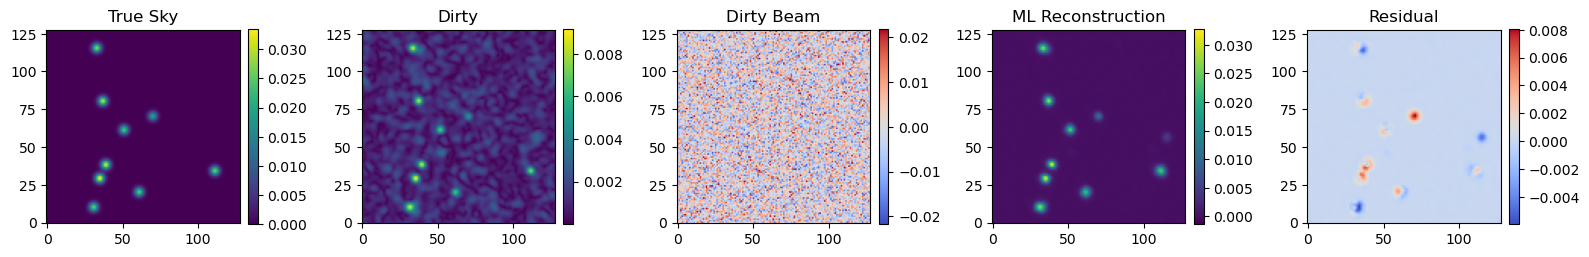

In [44]:
sample_id = 0

# Instantiate model based on architecture selection
if model_architecture.lower() == "simple_cnn":
    model = SimpleCNN().to(device)
elif model_architecture.lower() == "unet":
    model = UNet(in_channels=2, out_channels=1).to(device)
else:
    raise ValueError(f"Unknown architecture: {model_architecture}. Choose 'simple_cnn' or 'unet'.")

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

input_tensor, clean_tensor = test_dataset[sample_id]
dirty = input_tensor[0].numpy()
dirty_beam = input_tensor[1].numpy()
clean = clean_tensor.squeeze().numpy()
x = input_tensor.unsqueeze(0).to(device)

with torch.no_grad():
    recon = model(x).squeeze().cpu().numpy()

residual = clean - recon
beam_display_limit = np.percentile(np.abs(dirty_beam), 99)

plt.figure(figsize=(16, 4))

plt.subplot(1, 5, 1)
plt.imshow(clean, origin="lower")
plt.title("True Sky")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 5, 2)
plt.imshow(dirty, origin="lower")
plt.title("Dirty")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 5, 3)
plt.imshow(dirty_beam, origin="lower", cmap="coolwarm", vmin=-beam_display_limit, vmax=beam_display_limit)
plt.title("Dirty Beam")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 5, 4)
plt.imshow(recon, origin="lower")
plt.title("ML Reconstruction")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 5, 5)
plt.imshow(residual, origin="lower", cmap="coolwarm")
plt.title("Residual")
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("reconstruction_example.png", dpi=150)
plt.show()

## 8a. Diagnostic: Ring Artifacts and False Source Analysis

Ring artifacts suggest the model is not fully deconvolving the dirty beam. False bright sources often emerge from the model "hallucinating" peaks to minimize pixel-level MSE rather than preserving source structure.

This diagnostic cell correlates residual patterns with the dirty beam to quantify how much of the error is beam-like vs. spurious.

Beam-Residual Correlation Analysis:
  Peak cross-correlation: 1582.0741
  Mean cross-correlation: 69.6053
  Ratio (peak/mean):      22.73
  → RINGS DETECTED: Residuals strongly correlate with dirty beam pattern

False Source Detection:
  Spurious high-value pixels (85th percentile): 730
  % of image: 4.46%


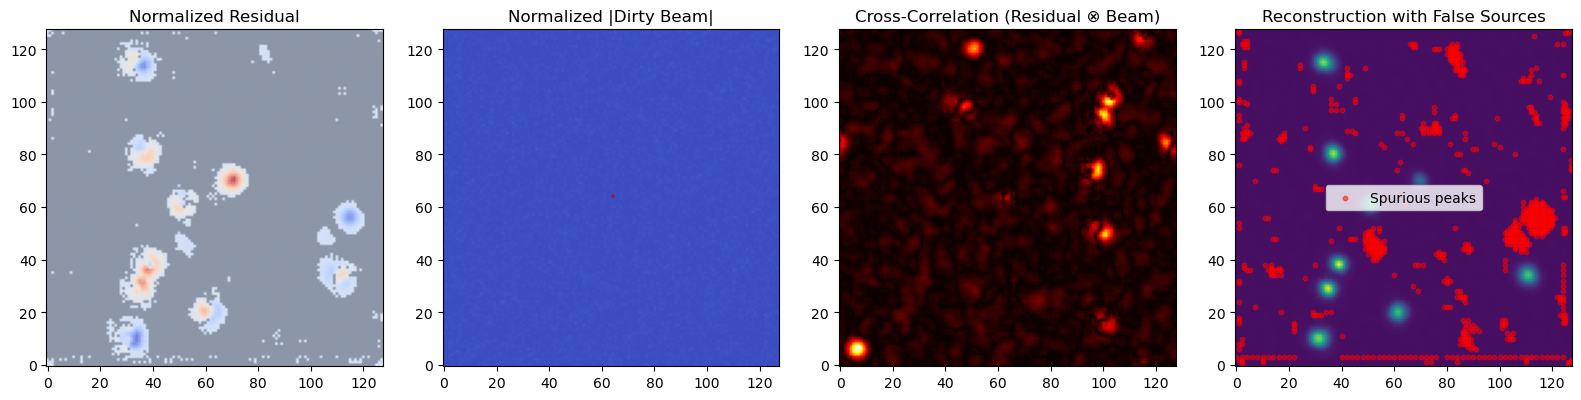

In [45]:
# Quantify beam correlation in residuals
# Check if residual rings correlate with dirty beam pattern

# Normalize both for correlation
residual_norm = (residual - np.mean(residual)) / (np.std(residual) + 1e-12)
beam_norm = (np.abs(dirty_beam) - np.mean(np.abs(dirty_beam))) / (np.std(np.abs(dirty_beam)) + 1e-12)

# Compute cross-correlation in frequency domain
residual_fft = np.fft.fft2(residual_norm)
beam_fft = np.fft.fft2(beam_norm)
cross_corr = np.abs(np.fft.ifft2(residual_fft * np.conj(beam_fft)))
peak_cross_corr = np.max(cross_corr)
mean_cross_corr = np.mean(cross_corr)

print(f"Beam-Residual Correlation Analysis:")
print(f"  Peak cross-correlation: {peak_cross_corr:.4f}")
print(f"  Mean cross-correlation: {mean_cross_corr:.4f}")
print(f"  Ratio (peak/mean):      {peak_cross_corr / (mean_cross_corr + 1e-12):.2f}")
if peak_cross_corr > 0.5:
    print("  → RINGS DETECTED: Residuals strongly correlate with dirty beam pattern")
else:
    print("  → Residuals are less beam-like (better deconvolution)")

# Detect false sources: bright spots in residual that don't exist in clean
threshold_residual = np.percentile(np.abs(residual), 90)
false_source_mask = np.abs(residual) > threshold_residual

# Count peaks in reconstruction that weren't in clean
recon_peaks = recon > np.percentile(recon, 85)
clean_peaks = clean > np.percentile(clean, 85)
spurious_peaks = recon_peaks & ~clean_peaks
n_spurious = np.sum(spurious_peaks)

print(f"\nFalse Source Detection:")
print(f"  Spurious high-value pixels (85th percentile): {n_spurious}")
print(f"  % of image: {100 * n_spurious / (128*128):.2f}%")

# Visualize correlation
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(residual_norm, origin="lower", cmap="coolwarm")
axes[0].set_title("Normalized Residual")
axes[0].imshow(false_source_mask, alpha=0.3, cmap="gray", origin="lower")

axes[1].imshow(beam_norm, origin="lower", cmap="coolwarm")
axes[1].set_title("Normalized |Dirty Beam|")

axes[2].imshow(cross_corr, origin="lower", cmap="hot")
axes[2].set_title("Cross-Correlation (Residual ⊗ Beam)")

axes[3].imshow(recon, origin="lower")
axes[3].scatter(*np.where(spurious_peaks)[::-1], c='red', s=10, alpha=0.5, label="Spurious peaks")
axes[3].set_title("Reconstruction with False Sources")
axes[3].legend()

plt.tight_layout()
plt.savefig("artifact_diagnostics.png", dpi=150)
plt.show()

## 9. Test Metrics

The test set is held out until the end. These metrics estimate how well the model generalizes to images it did not train on.

Readable metrics:

```text
MSE  = average squared pixel error
MAE  = average absolute pixel error
PSNR = image quality score derived from MSE; higher is better
SSIM = structural similarity score; closer to 1 is better
```

For radio images, also inspect the residual plot. A low MSE can still hide blurred or missed point sources.

In [46]:
def batch_ssim(pred, target, data_range=1.0):
    dims = (1, 2, 3)
    mu_pred = pred.mean(dim=dims)
    mu_target = target.mean(dim=dims)

    var_pred = ((pred - mu_pred[:, None, None, None]) ** 2).mean(dim=dims)
    var_target = ((target - mu_target[:, None, None, None]) ** 2).mean(dim=dims)
    cov = (
        (pred - mu_pred[:, None, None, None])
        * (target - mu_target[:, None, None, None])
    ).mean(dim=dims)

    c1 = (0.01 * data_range) ** 2
    c2 = (0.03 * data_range) ** 2

    numerator = (2 * mu_pred * mu_target + c1) * (2 * cov + c2)
    denominator = (mu_pred ** 2 + mu_target ** 2 + c1) * (var_pred + var_target + c2)
    return numerator / (denominator + 1e-12)

def evaluate_model(model, loader):
    model.eval()
    mse_values = []
    mae_values = []
    psnr_values = []
    ssim_values = []
    flux_ratio_values = []
    peak_ratio_values = []

    with torch.no_grad():
        for input_batch, clean_batch in loader:
            input_batch = input_batch.to(device)
            clean_batch = clean_batch.to(device)
            pred = model(input_batch)

            mse = ((pred - clean_batch) ** 2).mean(dim=(1, 2, 3))
            mae = (pred - clean_batch).abs().mean(dim=(1, 2, 3))
            psnr = 10 * torch.log10(1.0 / (mse + 1e-12))
            ssim = batch_ssim(pred, clean_batch, data_range=1.0)
            pred_flux = pred.sum(dim=(1, 2, 3))
            clean_flux = clean_batch.sum(dim=(1, 2, 3)).clamp_min(1e-12)
            flux_ratio = pred_flux / clean_flux
            pred_peak = pred.amax(dim=(1, 2, 3))
            clean_peak = clean_batch.amax(dim=(1, 2, 3)).clamp_min(1e-12)
            peak_ratio = pred_peak / clean_peak

            mse_values.extend(mse.cpu().numpy())
            mae_values.extend(mae.cpu().numpy())
            psnr_values.extend(psnr.cpu().numpy())
            ssim_values.extend(ssim.cpu().numpy())
            flux_ratio_values.extend(flux_ratio.cpu().numpy())
            peak_ratio_values.extend(peak_ratio.cpu().numpy())

    return {
        "mse": float(np.mean(mse_values)),
        "mae": float(np.mean(mae_values)),
        "psnr": float(np.mean(psnr_values)),
        "ssim": float(np.mean(ssim_values)),
        "flux_ratio": float(np.mean(flux_ratio_values)),
        "peak_ratio": float(np.mean(peak_ratio_values)),
    }

test_metrics = evaluate_model(model, test_loader)

print(f"Test MSE:  {test_metrics['mse']:.6f}")
print(f"Test MAE:  {test_metrics['mae']:.6f}")
print(f"Test PSNR: {test_metrics['psnr']:.2f} dB")
print(f"Test SSIM: {test_metrics['ssim']:.4f}")
print(f"Test flux ratio: {test_metrics['flux_ratio']:.4f}  (1.0 is ideal)")
print(f"Test peak ratio: {test_metrics['peak_ratio']:.4f}  (1.0 is ideal)")

Test MSE:  0.000000
Test MAE:  0.000104
Test PSNR: 68.76 dB
Test SSIM: 0.9998
Test flux ratio: 0.9437  (1.0 is ideal)
Test peak ratio: 1.0231  (1.0 is ideal)


In [47]:
# Per-source flux error analysis
flux_errors = []
with torch.no_grad():
    for input_batch, clean_batch in test_loader:
        input_batch = input_batch.to(device)
        clean_batch = clean_batch.to(device)
        pred = model(input_batch)
        
        pred_flux = pred.sum(dim=(1, 2, 3))
        clean_flux = clean_batch.sum(dim=(1, 2, 3))
        relative_error = (pred_flux - clean_flux) / clean_flux
        flux_errors.extend(relative_error.cpu().numpy())

flux_errors = np.array(flux_errors)
print(f"Mean flux error:    {np.mean(flux_errors):.4f}")
print(f"Std flux error:     {np.std(flux_errors):.4f}")
print(f"Min flux error:     {np.min(flux_errors):.4f}")
print(f"Max flux error:     {np.max(flux_errors):.4f}")
print(f"% sources within ±5%:   {100*np.mean(np.abs(flux_errors) < 0.05):.1f}%")
print(f"% sources within ±10%:  {100*np.mean(np.abs(flux_errors) < 0.10):.1f}%")
print(f"% sources within ±15%:  {100*np.mean(np.abs(flux_errors) < 0.15):.1f}%")
print(f"% sources within ±20%:  {100*np.mean(np.abs(flux_errors) < 0.20):.1f}%")
print(f"% sources within ±25%:  {100*np.mean(np.abs(flux_errors) < 0.25):.1f}%")

Mean flux error:    -0.0563
Std flux error:     0.1168
Min flux error:     -0.4240
Max flux error:     0.1640
% sources within ±5%:   40.7%
% sources within ±10%:  67.3%
% sources within ±15%:  80.7%
% sources within ±20%:  86.7%
% sources within ±25%:  92.7%
